In [1]:
import numpy as np
import os
import scipy.io

In [2]:
import tarfile
import numpy as np 

In [3]:
labelsn = scipy.io.loadmat("imagelabels.mat")
labelsn = labelsn["labels"]
labelsn = labelsn[0]
for i in range(len(labelsn)):
  labelsn[i] = labelsn[i] - 1

In [4]:

import cv2
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
train_x = []
train_y = []
dir = "flowers/"
for imgs in os.listdir(dir):
    imgnum = int(imgs[7:11])-1
    train_y.append(labelsn[imgnum])
    image = cv2.imread(os.path.join(dir, imgs))
    new_size = cv2.resize(image, (150,150))
    normalized_image = cv2.normalize(new_size, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    train_x.append(normalized_image)
train_x = np.array(train_x)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
trainx, valx, trainy, valy = train_test_split(train_x, train_y, test_size=0.25, random_state=10)

In [8]:
trainingimages= trainx/255.0
testingimages=valx/255.0

trainingimages = trainx.reshape((6141, 150, 150, 3))
valx = valx.reshape((2048,150,150,3))
print('Shape of Training Data: {}'.format(trainx.shape))
print('No. of training examples: {}'.format(len(trainy)))
print('Shape of Testing Data: {}'.format(valx.shape))
print('No. of testing examples: {}'.format(len(valy)))

Shape of Training Data: (6141, 150, 150, 3)
No. of training examples: 6141
Shape of Testing Data: (2048, 150, 150, 3)
No. of testing examples: 2048


In [9]:
trainy = to_categorical(trainy)
valy = to_categorical(valy)
print(valy.shape)

(2048, 102)


In [10]:
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

In [11]:
from keras.layers import Dropout, Flatten,Activation
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization

In [12]:
img_width, img_height = 150, 150

In [13]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(102, activation='softmax')
])


In [14]:
model.compile(optimizer=Adam(lr=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

C:\Users\blaks\anaconda3\lib\site-packages\keras\optimizers\legacy\adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [15]:
batchSize=64
ep=60
model.fit(trainx,trainy,batch_size=batchSize,epochs=ep,validation_split=.15)

Train on 5219 samples, validate on 922 samples
Epoch 1/60
5219/5219 [==============================] - ETA: 0s - loss: 4.5454 - acc: 0.0307

C:\Users\blaks\anaconda3\lib\site-packages\keras\engine\training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


5219/5219 [==============================] - 173s 33ms/sample - loss: 4.5454 - acc: 0.0307 - val_loss: 4.3863 - val_acc: 0.0423
Epoch 2/60
5219/5219 [==============================] - 156s 30ms/sample - loss: 4.2896 - acc: 0.0594 - val_loss: 4.0958 - val_acc: 0.0922
Epoch 3/60
5219/5219 [==============================] - 140s 27ms/sample - loss: 4.0758 - acc: 0.0895 - val_loss: 3.8462 - val_acc: 0.1345
Epoch 4/60
5219/5219 [==============================] - 148s 28ms/sample - loss: 3.8520 - acc: 0.1278 - val_loss: 3.6594 - val_acc: 0.1735
Epoch 5/60
5219/5219 [==============================] - 171s 33ms/sample - loss: 3.6377 - acc: 0.1583 - val_loss: 3.4778 - val_acc: 0.1996
Epoch 6/60
5219/5219 [==============================] - 211s 40ms/sample - loss: 3.4300 - acc: 0.1884 - val_loss: 3.3388 - val_acc: 0.2289
Epoch 7/60
5219/5219 [==============================] - 192s 37ms/sample - loss: 3.2588 - acc: 0.2190 - val_loss: 3.1593 - val_acc: 0.2722
Epoch 8/60
5219/5219 [================

5219/5219 [==============================] - 177s 34ms/sample - loss: 0.2767 - acc: 0.9147 - val_loss: 3.2021 - val_acc: 0.3937
Epoch 60/60
5219/5219 [==============================] - 181s 35ms/sample - loss: 0.2746 - acc: 0.9151 - val_loss: 3.2110 - val_acc: 0.3894


In [16]:
model.evaluate(valx,valy)

[3.11719461530447, 0.41992188]

In [17]:
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

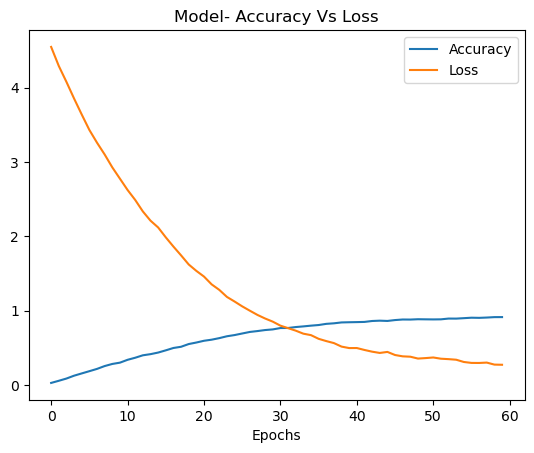

In [18]:
plt.plot(range(len(model.history.history['acc'])),model.history.history['acc'])
plt.plot(range(len(model.history.history['loss'])),model.history.history['loss'])
plt.title('Model- Accuracy Vs Loss')
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

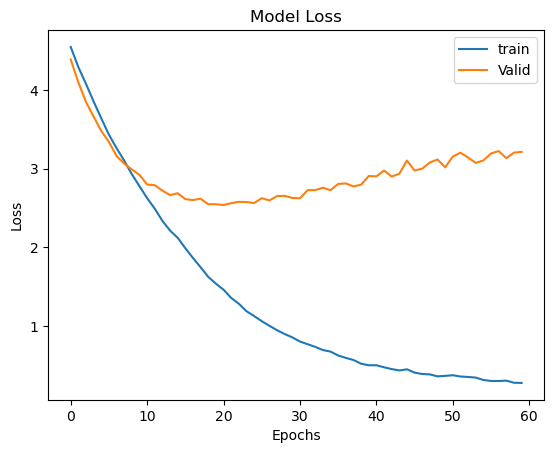

In [19]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

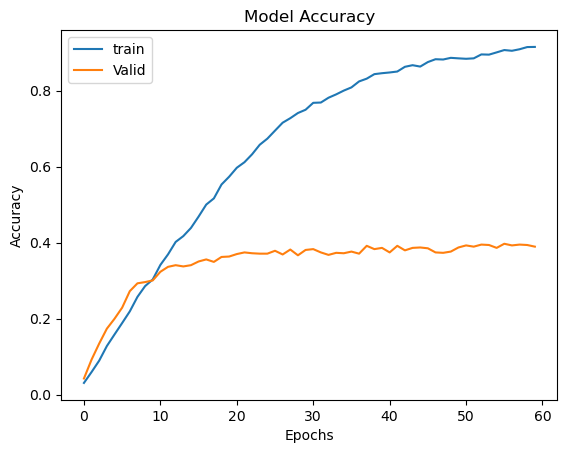

In [20]:
plt.plot(model.history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'Valid'])
plt.show()

In [21]:
pred=model.predict(valx)
print("Predicted Probabilities -\n",pred[:4])
pred_digits=np.argmax(pred,axis=1)
print("\nPredicted Class [Highest Prob] -",pred_digits[:4])

C:\Users\blaks\anaconda3\lib\site-packages\keras\engine\training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Predicted Probabilities -
 [[2.35607866e-02 1.08609945e-02 4.29338031e-03 7.47364073e-04
  3.61972002e-06 1.33985031e-05 2.46920437e-03 3.44119559e-04
  2.00297145e-05 4.41295015e-06 1.59233138e-02 1.61933986e-05
  2.02689669e-04 3.35262030e-06 5.08611606e-07 6.17478008e-06
  2.93458044e-03 1.05817374e-02 4.29328391e-03 1.09222974e-03
  4.93103153e-06 5.74599660e-04 2.05481905e-04 6.21328766e-08
  2.59061286e-04 2.25510530e-06 7.97825269e-05 1.44306869e-05
  9.24766937e-04 1.68755918e-03 6.38402114e-03 1.97547656e-02
  4.91010769e-06 4.34670765e-05 1.86064483e-07 6.64621417e-04
  3.03421766e-02 5.22885894e-05 3.14918682e-02 3.42756248e-04
  3.52270552e-04 1.54610552e-06 2.51750685e-02 7.13960151e-04
  1.47501787e-05 4.09312224e-06 4.87290981e-06 2.68725512e-06
  1.89213431e-04 1.11147892e-06 8.25119242e-02 5.19356865e-04
  1.16253395e-04 3.84412442e-06 5.43606468e-03 3.31561887e-06
  9.04541346e-04 4.19930120e-06 3.49332208e-06 9.58922756e-05
  2.34358922e-07 5.16863614e-02 3.48015590e

In [22]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(valy)):
    if(np.argmax(valy[i])==pred_digits[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(valy)):
    if(not np.argmax(valy[i])==pred_digits[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

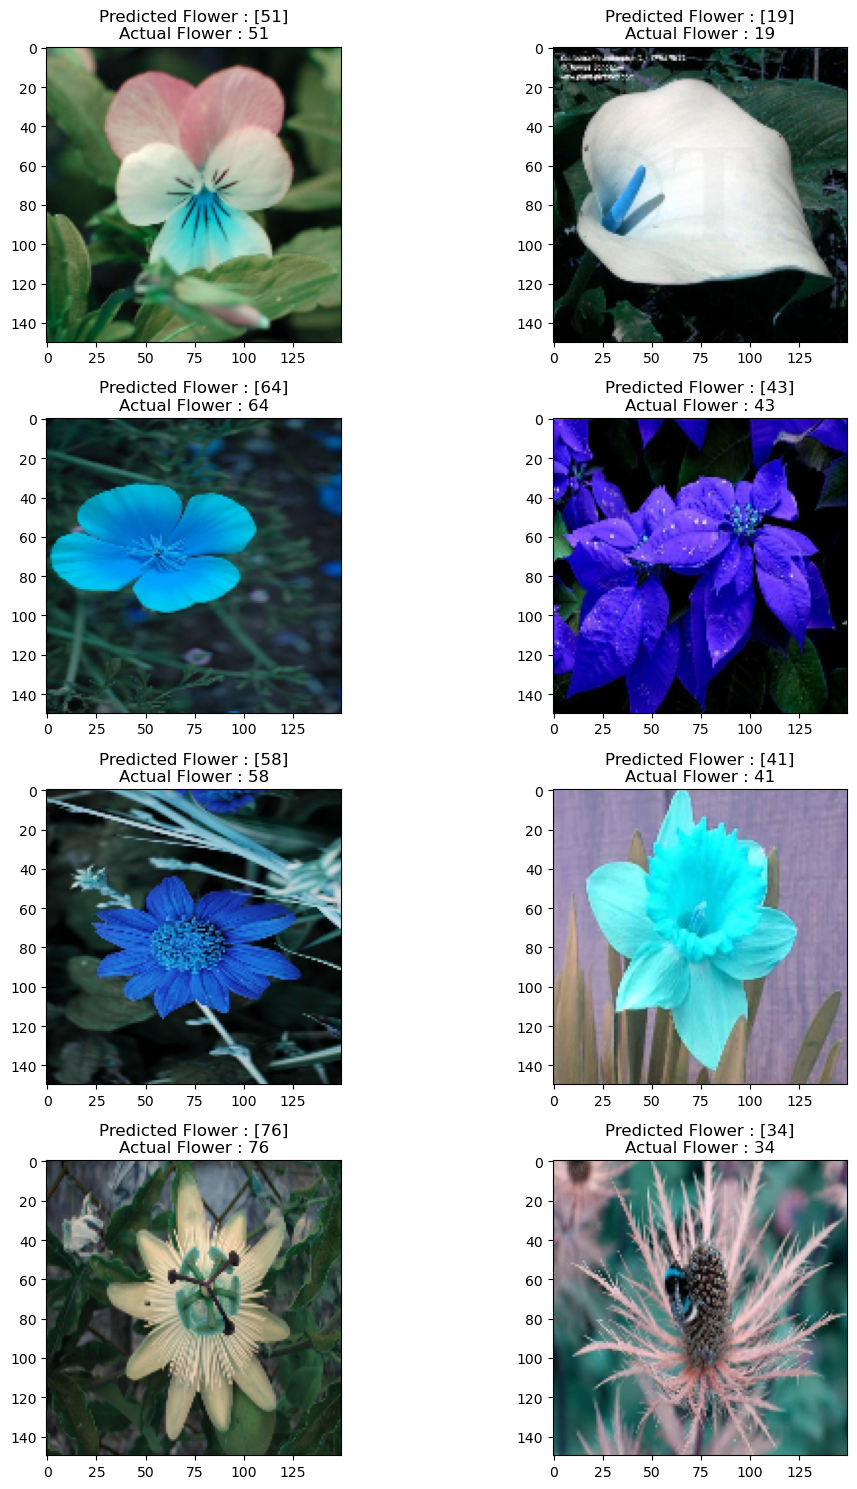

In [23]:
import warnings
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count=0
fig,ax=plt.subplots(4,2)
fig.set_size_inches(15,15)
for i in range (4):
    for j in range (2):
        ax[i,j].imshow(valx[prop_class[count]])
        ax[i,j].set_title("Predicted Flower : "+str([pred_digits[prop_class[count]]])+"\n"+"Actual Flower : "+str(np.argmax([valy[prop_class[count]]])))
        plt.tight_layout()
        count+=1